In [1]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np

LOG.propagate = False
from uuid import uuid4
uuid4()

UUID('2f4d30ed-df79-4024-88f0-5367e8d34a28')

In [2]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()

2026-04-29 16:25:52,228 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:d1:79:ab:49
2026-04-29 16:25:52,229 | INFO     |: Scanning for device with address: c0:42:d1:79:ab:49, service UUID: 4843fd62-068c-4a37-af34-e724c6a05681
2026-04-29 16:26:02,390 | INFO     |: Found 159 total devices
2026-04-29 16:26:02,393 | INFO     |: Found matching device: C0:42:D1:79:AB:49 (name: Artemis BLE)
2026-04-29 16:26:03,911 | INFO     |: Connected to c0:42:d1:79:ab:49


In [3]:
# ── CELL 1: Imports & Commands ──────────────────────────────────────────────
import time
import numpy as np
import matplotlib.pyplot as plt
from enum import Enum
class CommandTypes(Enum):
    PING              = 0
    SEND_TWO_INTS     = 1
    SEND_THREE_FLOATS = 2
    ECHO              = 3
    DUMP_LOGS         = 4
    GET_TIME_MILLIS   = 5
    GET_IMU_DATA      = 6
    START_LOGGING     = 7
    START_RUN         = 8
    GET_RUN_DATA      = 9
    START_PID         = 10  
    SET_GAINS         = 11 


print("Commands ready.")
# ── CELL 2: Notification handler ────────────────────────────────────────────
raw_packets = []

def notification_handler(uuid, byte_array):
    s = ble.bytearray_to_string(byte_array)
    raw_packets.append(s)

# Safety reset then subscribe
try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except:
    pass

raw_packets.clear()
ble.start_notify(ble.uuid['RX_STRING'], notification_handler)
print("Subscribed. Listening for packets...")


Commands ready.
Subscribed. Listening for packets...


In [31]:
# STEP_PWM_VALUE  = 120    # ~60% of max (50–200 range recommended)
# SAFETY_STOP_MM  = 300    # emergency stop distance in mm (0 = disabled)
 
# ble.send_command(CommandTypes.SET_GAINS, f"11|PWM:{STEP_PWM_VALUE}|SP:{SAFETY_STOP_MM}")
# print(f"Configured: step PWM={STEP_PWM_VALUE}, safety stop={SAFETY_STOP_MM}mm")
ble.send_command(CommandTypes.SET_GAINS, "11|PWM:0")

In [63]:
#lab12balnce 
import time

# --- Configuration Constants ---
# Use the values we discussed to fix the physics model
ALPHA_GRAVITY = 50.0  # KF_ALPHA1
ALPHA_MOTOR   = 6.21  # KF_ALPHA2

# PID Gains (Start conservative for Phase A)
KP = 0.2
KI = 0.0
KD = 0.08
SETPOINT = -1.5  # Adjust this to where your car feels weightless

# KF Sigmas
S1 = 3.0   # Process noise pitch
S2 = 15.0  # Process noise rate
S3 = 2.0   # Sensor noise

# --- CELL: Set Parameters & Start Phase A ---

# 1. Format the SET_GAINS string based on your Arduino logic: "11|Kp:4.0|Kd:0.08|..."
# Note: Ensure you include the command ID '11' at the start
params = f"11|Kp:{KP}|Ki:{KI}|Kd:{KD}|SP:{SETPOINT}|S1:{S1}|S2:{S2}|S3:{S3}"

print(f"Sending Gains: {params}")
ble.send_command(CommandTypes.SET_GAINS, params)

# Give the Artemis a moment to process and reset matrices
time.sleep(0.5)

# 2. Trigger Phase A (Hand-placed balancing)
print("Engaging Phase A: Place the car upright NOW...")
ble.send_command(CommandTypes.START_PID, "")

# --- CELL: Stop and Fetch Data (Run after testing) ---
# time.sleep(10) # Let it run for 10 seconds
# ble.send_command(CommandTypes.STOP_ROBOT, "")
# ble.send_command(CommandTypes.GET_RUN_DATA, "")

Sending Gains: 11|Kp:0.2|Ki:0.0|Kd:0.08|SP:-1.5|S1:3.0|S2:15.0|S3:2.0
Engaging Phase A: Place the car upright NOW...


In [69]:
ble.send_command(CommandTypes.GET_RUN_DATA, "")

In [70]:
raw_packets.clear()
try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except:
    pass
ble.start_notify(ble.uuid['RX_STRING'], notification_handler)
print("Sending START_RUN (open-loop step)...")
ble.send_command(CommandTypes.START_RUN, "")

Sending START_RUN (open-loop step)...


# Lab 12

In [17]:
#lab 12
import time

# --- 1. PHYSICAL MODEL (Fixed from previous analysis) ---
# alpha1 = Gravity (~50), alpha2 = Motor (~6)
MODEL_PARAMS = "S1:3.0|S2:15.0|S3:2.0" # Sigmas for KF

# --- 2. PID GAINS (Phase A tuning) ---
PID_PARAMS = "Kp:4.5|Kd:0.12|Ki:0.0|SP:-1.5" 

# --- 3. POP SEQUENCE TUNING (The "Stunt" Knobs) ---
# PD: Drive time (ms) - Build forward momentum
# PB: Brake time (ms) - The 'kick' that lifts the nose
# HO: Handoff Angle (deg) - When to start balancing (e.g., 55 deg from flat)
# DPWM: Drive Power (0-255)
# BPWM: Brake Power (0-255)
POP_PARAMS = "PD:300|PB:50|PBK:150|HO:80|DPWM:255|BPWM:255|BKPWM:255"

# Combine into one SET_GAINS command
full_cmd = f"11|{PID_PARAMS}|{MODEL_PARAMS}|{POP_PARAMS}"

print(f"Configuring Robot: {full_cmd}")
ble.send_command(CommandTypes.SET_GAINS, full_cmd)
time.sleep(0.5)

# Clear old notifications and start fresh
raw_packets.clear()
print("Executing START_RUN (Phase B)... ")
ble.send_command(CommandTypes.START_RUN, "")

Configuring Robot: 11|Kp:4.5|Kd:0.12|Ki:0.0|SP:-1.5|S1:3.0|S2:15.0|S3:2.0|PD:300|PB:50|PBK:150|HO:80|DPWM:255|BPWM:255|BKPWM:255
Executing START_RUN (Phase B)... 


In [5]:
# ── CELL: Run P controller ───────────────────────────────────────────────────
raw_packets.clear()
try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except: pass
ble.start_notify(ble.uuid['RX_STRING'], notification_handler)

print("Sending START_PID...")
ble.send_command(CommandTypes.START_PID, "")


Sending START_PID...


In [18]:
import time
print("Requesting data...")
ble.send_command(CommandTypes.GET_RUN_DATA, "")
time.sleep(30)    # wait for BLE stream to finish
ble.stop_notify(ble.uuid['RX_STRING'])
print(f"Received {len(raw_packets)} packets.")
import numpy as np
import csv
 
times_raw, dist_raw, dist_extrap_log, motor_log = [], [], [], []
 
for line in raw_packets:
    try:
        parts = {p.split(':')[0]: float(p.split(':')[1])
                 for p in line.strip().split('|') if ':' in p}
        if 'T' not in parts:
            continue
        times_raw.append(parts['T'])
        dist_raw.append(parts.get('D1', 0))           # raw ToF (mm)
        dist_extrap_log.append(parts.get('D2', 0))    # extrapolated ToF (mm)
        motor_log.append(parts.get('MOT', 0))         # constant step PWM
    except:
        continue
 
# Time normalised to seconds from start
t0  = times_raw[0]
t   = np.array([(x - t0) / 1000.0 for x in times_raw])
d1  = np.array(dist_raw)           # raw distance toward wall (mm)
d2  = np.array(dist_extrap_log)    # extrapolated distance (mm)
mot = np.array(motor_log)
 
# Speed: positive = moving toward wall (distance decreasing → negate gradient)
speed = -np.gradient(d1, t)        # mm/s
 
# Save to CSV
csv_path = "step_response_data.csv"
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['time_s', 'dist_raw_mm', 'dist_extrap_mm', 'motor_pwm', 'speed_mm_s'])
    for row in zip(t, d1, d2, mot, speed):
        writer.writerow(row)
print(f"Saved {len(t)} samples → {csv_path}")

Requesting data...
Received 0 packets.


IndexError: list index out of range

In [34]:
ble.send_command(CommandTypes.SET_GAINS, "11|PWM:120")

In [36]:
#lab12
# import time
# import numpy as np
# import csv
# from scipy.signal import medfilt  # Required for smoothing the derivatives

# print("Requesting data...")
# ble.send_command(CommandTypes.GET_RUN_DATA, "")
# time.sleep(30)    # wait for BLE stream to finish
# try:
#     ble.stop_notify(ble.uuid['RX_STRING'])
# except:
#     pass
# print(f"Received {len(raw_packets)} packets.")

# # Updated arrays for IMU data
# times_raw, pitch_raw, motor_log = [], [], []

# for line in raw_packets:
#     try:
#         parts = {p.split(':')[0]: float(p.split(':')[1])
#                  for p in line.strip().split('|') if ':' in p}
#         if 'T' not in parts:
#             continue
#         times_raw.append(parts['T'])
#         pitch_raw.append(parts.get('D1', 0))          # Pitch angle (deg)
#         motor_log.append(parts.get('MOT', 0))         # constant step PWM
#     except:
#         continue

# # Time normalised to seconds from start
# if len(times_raw) > 0:
#     t0  = times_raw[0]
#     t   = np.array([(x - t0) / 1000.0 for x in times_raw])
#     pitch = np.array(pitch_raw)           
#     mot   = np.array(motor_log)
    
#     # 1st Derivative: Angular Velocity (deg/s) with 5-point median filter
#     pitch_rate = np.gradient(pitch, t)
#     pitch_rate = medfilt(pitch_rate, 5) 
    
#     # 2nd Derivative: Angular Acceleration (deg/s^2) with 5-point median filter
#     pitch_accel = np.gradient(pitch_rate, t)
#     pitch_accel = medfilt(pitch_accel, 5)
    
#     # Save to CSV
#     csv_path = "imu_step_response_data.csv"
#     with open(csv_path, 'w', newline='') as f:
#         writer = csv.writer(f)
#         writer.writerow(['time_s', 'pitch_deg', 'pitch_rate_deg_s', 'pitch_accel_deg_s2', 'motor_pwm'])
#         for row in zip(t, pitch, pitch_rate, pitch_accel, mot):
#             writer.writerow(row)
#     print(f"Saved {len(t)} samples → {csv_path}")
# else:
#     print("No valid data received. Check BLE connection and raw_packets.")
import time
import numpy as np
import csv
from scipy.signal import medfilt

# ── 1. Clear old data and ensure we are listening ────────────────────────────
raw_packets.clear()
try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except: pass
ble.start_notify(ble.uuid['RX_STRING'], notification_handler)

# ── 2. Trigger the physical run ──────────────────────────────────────────────
print("1. Sending START_RUN (CMD 8)...")
ble.send_command(CommandTypes.START_RUN, "")

# The Arduino RUN_DURATION_MS is set to 1500. We wait 2 seconds to ensure it finishes.
time.sleep(7)

# ── 3. Request the logged data ───────────────────────────────────────────────
print("2. Requesting data (CMD 9)...")
ble.send_command(CommandTypes.GET_RUN_DATA, "")

# Wait for the BLE transfer to complete
time.sleep(15) 

try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except: pass

print(f"Received {len(raw_packets)} packets.")

# ── 4. Parse and Save ────────────────────────────────────────────────────────
times_raw, pitch_raw, motor_log = [], [], []

for line in raw_packets:
    try:
        parts = {p.split(':')[0]: float(p.split(':')[1])
                 for p in line.strip().split('|') if ':' in p}
        if 'T' not in parts:
            continue
        times_raw.append(parts['T'])
        pitch_raw.append(parts.get('D1', 0))          # Pitch angle (deg)
        motor_log.append(parts.get('MOT', 0))         # constant step PWM
    except:
        continue

if len(times_raw) > 0:
    t0  = times_raw[0]
    t   = np.array([(x - t0) / 1000.0 for x in times_raw])
    pitch = np.array(pitch_raw)           
    mot   = np.array(motor_log)
    
    # 1st Derivative: Angular Velocity (deg/s) with 5-point median filter
    pitch_rate = np.gradient(pitch, t)
    pitch_rate = medfilt(pitch_rate, 5) 
    
    # 2nd Derivative: Angular Acceleration (deg/s^2) with 5-point median filter
    pitch_accel = np.gradient(pitch_rate, t)
    pitch_accel = medfilt(pitch_accel, 5)
    
    # Save to CSV
    csv_path = "imu_step_response_data3.csv"
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['time_s', 'pitch_deg', 'pitch_rate_deg_s', 'pitch_accel_deg_s2', 'motor_pwm'])
        for row in zip(t, pitch, pitch_rate, pitch_accel, mot):
            writer.writerow(row)
    print(f"Saved {len(t)} samples → {csv_path}")
else:
    print("No valid data received. Check if the robot actually moved.")

1. Sending START_RUN (CMD 8)...
2. Requesting data (CMD 9)...
Received 283 packets.
Saved 283 samples → imu_step_response_data3.csv


--- SYSTEM IDENTIFICATION RESULTS ---
Alpha 1: No u=0 data found.
Estimated Alpha 2 (Motor Torque term): 46.16


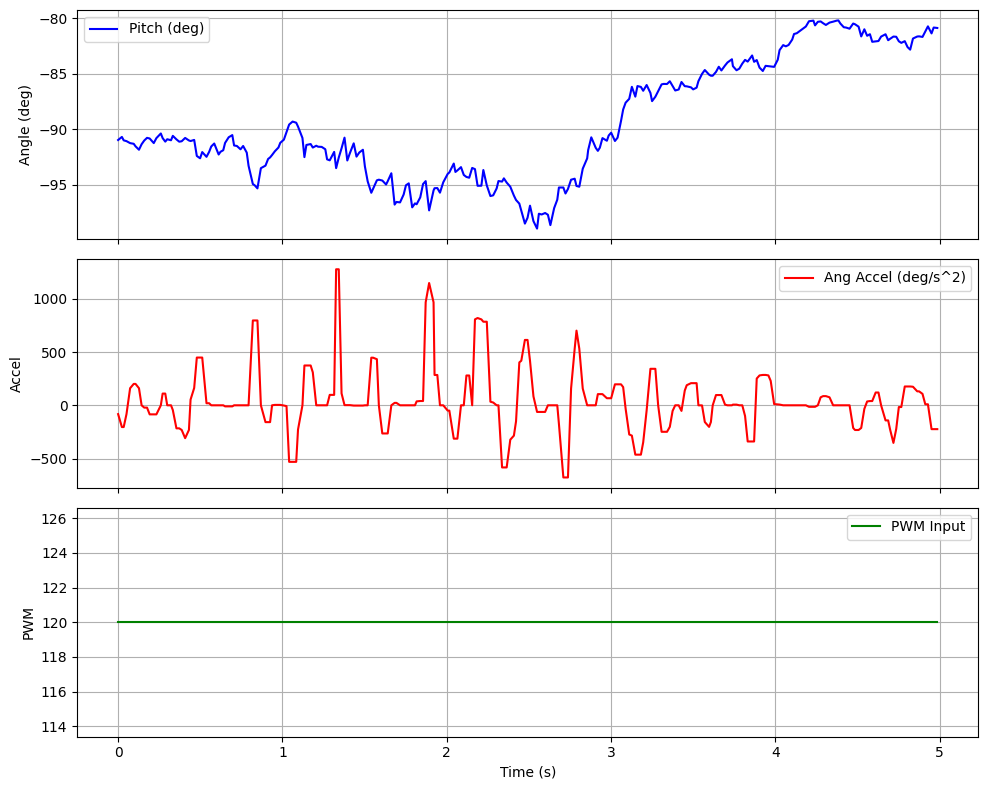

In [37]:
#lab12plot
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt

# ── 1. Parse Data ────────────────────────────────────────────────────────────
times_raw, dist_raw, motor_log = [], [], []

for line in raw_packets:
    try:
        parts = {p.split(':')[0]: float(p.split(':')[1])
                 for p in line.strip().split('|') if ':' in p}
        if 'T' not in parts:
            continue
        times_raw.append(parts['T'])
        dist_raw.append(parts.get('D1', 0))    # Pitch (degrees)
        motor_log.append(parts.get('MOT', 0))  # PWM
    except:
        continue

# Convert to Numpy Arrays
t  = np.array([(x - times_raw[0]) / 1000.0 for x in times_raw])
pitch = np.array(dist_raw) 
mot = np.array(motor_log)

# ── 2. Derive Rates (With Median Filter for Noise) ───────────────────────────
# 1st Derivative: Angular Velocity (deg/s)
pitch_rate = np.gradient(pitch, t)
pitch_rate = medfilt(pitch_rate, 5) 

# 2nd Derivative: Angular Acceleration (deg/s^2)
pitch_accel = np.gradient(pitch_rate, t)
pitch_accel = medfilt(pitch_accel, 5)

# Normalise control input (0 to 1) just like Lab 7!
u = mot / 255.0 

# ── 3. Calculate Alpha Matrices ──────────────────────────────────────────────
# We isolate the data based on the PWM input to find the respective Alpha
is_falling = (u == 0)
is_driving = (u > 0)

print("--- SYSTEM IDENTIFICATION RESULTS ---")

# ALPHA 1: Calculate during the fall (u=0). Equation: accel = alpha1 * pitch
if np.any(is_falling):
    # Only look at the data where the pitch is actively falling to avoid rest state
    active_fall_idx = np.where(is_falling & (abs(pitch) > 2.0))[0]
    if len(active_fall_idx) > 5:
        # We can extract alpha 1 as the slope of Accel vs Pitch
        p_fall = pitch[active_fall_idx]
        a_fall = pitch_accel[active_fall_idx]
        
        # Polyfit returns [slope, intercept]
        alpha1_est, _ = np.polyfit(p_fall, a_fall, 1)
        print(f"Estimated Alpha 1 (Gravity term): {alpha1_est:.2f}")
    else:
        print("Alpha 1: Not enough active falling data detected.")
else:
    print("Alpha 1: No u=0 data found.")

# ALPHA 2: Calculate during motor step (u>0). Equation: accel = -alpha2 * u
if np.any(is_driving):
    # Look at the first 200ms of the step response before the car levels out
    step_start_idx = np.where(is_driving)[0][0]
    step_window = slice(step_start_idx, step_start_idx + 15) # Roughly 150-200ms
    
    a_drive = pitch_accel[step_window]
    u_drive = u[step_window]
    
    # Calculate alpha2: average of -(accel / u) 
    # (Assuming forward u causes negative pitch accel, adjust sign based on physical orientation)
    alpha2_vals = -a_drive / u_drive
    alpha2_est = np.median(alpha2_vals) # Median is safer against initial jerk spike
    print(f"Estimated Alpha 2 (Motor Torque term): {alpha2_est:.2f}")
else:
    print("Alpha 2: No step response (u>0) data found.")

# ── 4. Plotting ──────────────────────────────────────────────────────────────
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].plot(t, pitch, 'b', label='Pitch (deg)')
axs[0].set_ylabel('Angle (deg)')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t, pitch_accel, 'r', label='Ang Accel (deg/s^2)')
axs[1].set_ylabel('Accel')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(t, mot, 'g', label='PWM Input')
axs[2].set_ylabel('PWM')
axs[2].set_xlabel('Time (s)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

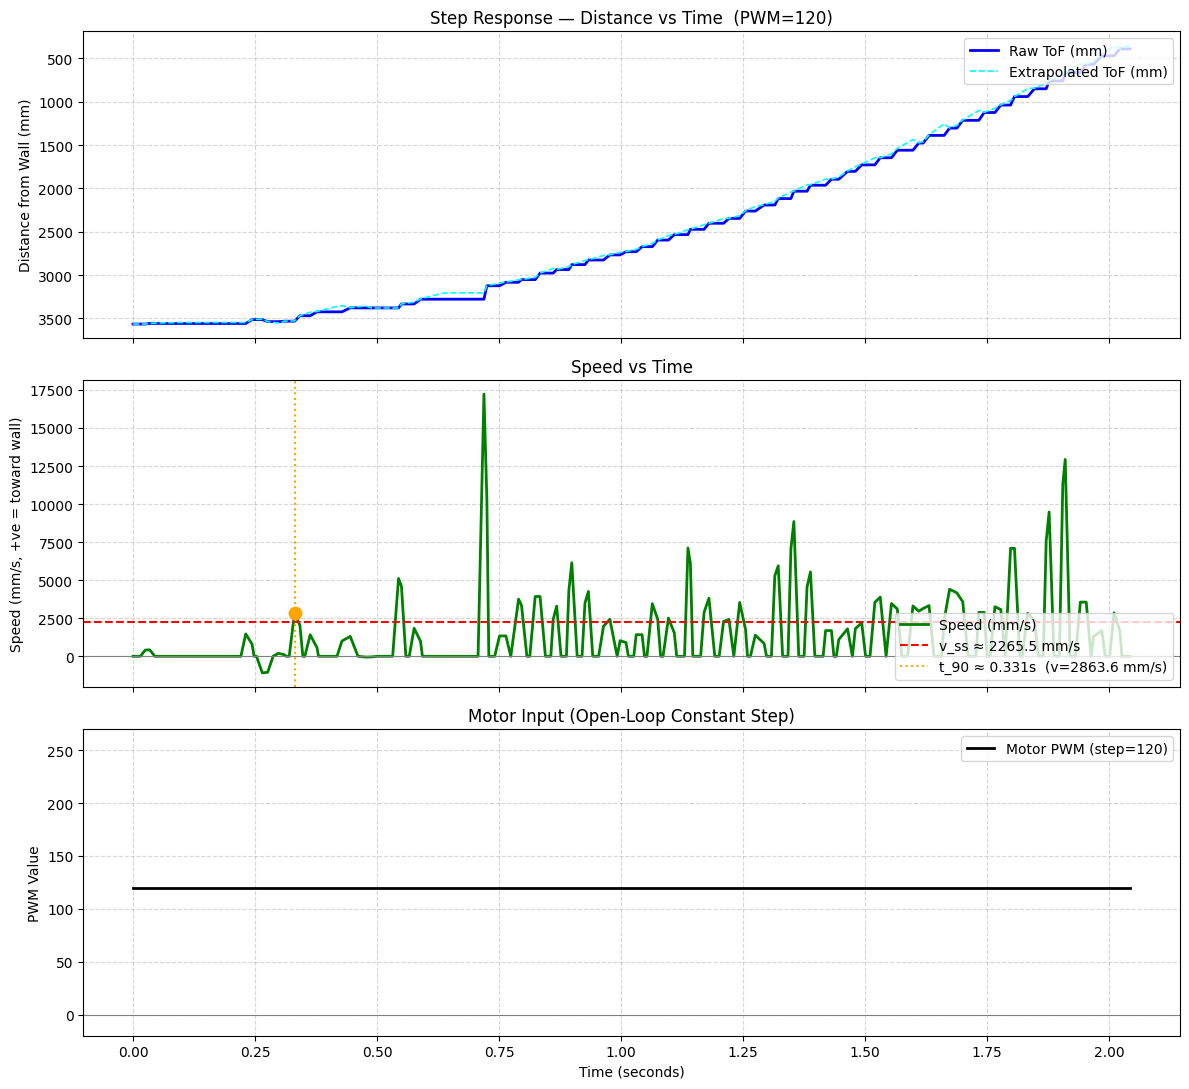

───────────────────────────────────────────────────────
  v_ss  (steady-state speed) = 2265.54  mm/s
  t_90  (90% rise time)      = 0.3310 s
  v_90  (speed at t_90)      = 2863.64  mm/s
  Loop rate                  ≈ 109.6  Hz
  Total samples              = 225
───────────────────────────────────────────────────────


In [50]:
import matplotlib.pyplot as plt
 
STEP_PWM_VALUE = int(mot[mot != 0][0]) if any(mot != 0) else 150
 
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
 
# — Plot 1: Distance vs Time ——————————————————————————————————————————————————
ax1.plot(t, d1, label='Raw ToF (mm)',          color='blue',  linewidth=2)
ax1.plot(t, d2, label='Extrapolated ToF (mm)', color='cyan',  linewidth=1.2, linestyle='--')
ax1.set_title(f'Step Response — Distance vs Time  (PWM={STEP_PWM_VALUE})')
ax1.set_ylabel('Distance from Wall (mm)')
ax1.invert_yaxis()   # moving toward wall = upward = intuitive
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)
 
# — Plot 2: Speed vs Time + annotations ———————————————————————————————————————
ax2.plot(t, speed, label='Speed (mm/s)', color='green', linewidth=2)
ax2.axhline(0, color='gray', linestyle='-', linewidth=0.8)
 
# Steady-state speed: mean of last 20% of samples
ss_start = int(0.80 * len(t))
v_ss     = np.mean(speed[ss_start:])
ax2.axhline(v_ss, color='red', linestyle='--', linewidth=1.5,
            label=f'v_ss ≈ {v_ss:.1f} mm/s')
 
# 90% rise time: first moment speed reaches 90% of steady-state
v_90   = 0.90 * v_ss
idx_90 = np.argmax(speed >= v_90)
t_90   = t[idx_90] if idx_90 > 0 else float('nan')
if not (t_90 != t_90):   # not nan
    ax2.axvline(t_90, color='orange', linestyle=':', linewidth=1.5,
                label=f't_90 ≈ {t_90:.3f}s  (v={speed[idx_90]:.1f} mm/s)')
    ax2.scatter([t_90], [speed[idx_90]], color='orange', zorder=5, s=80)
 
ax2.set_title('Speed vs Time')
ax2.set_ylabel('Speed (mm/s, +ve = toward wall)')
ax2.legend(loc='lower right')
ax2.grid(True, linestyle='--', alpha=0.5)

# — Plot 3: Motor input vs Time ────────────────────────────────────────────────
ax3.plot(t, mot, label=f'Motor PWM (step={STEP_PWM_VALUE})',
         color='black', drawstyle='steps-post', linewidth=2)
ax3.axhline(0, color='gray', linestyle='-', linewidth=0.8)
ax3.set_title('Motor Input (Open-Loop Constant Step)')
ax3.set_xlabel('Time (seconds)')
ax3.set_ylabel('PWM Value')
ax3.set_ylim([-20, 270])
ax3.legend(loc='upper right')
ax3.grid(True, linestyle='--', alpha=0.5)
 
plt.tight_layout()
plt.savefig("step_response_plot.png", dpi=150)
plt.show()
 
# Summary
print("─" * 55)
print(f"  v_ss  (steady-state speed) = {v_ss:.2f}  mm/s")
if not (t_90 != t_90):
    print(f"  t_90  (90% rise time)      = {t_90:.4f} s")
    print(f"  v_90  (speed at t_90)      = {speed[idx_90]:.2f}  mm/s")
loop_rate = 1.0 / np.mean(np.diff(t)) if len(t) > 1 else 0
print(f"  Loop rate                  ≈ {loop_rate:.1f}  Hz")
print(f"  Total samples              = {len(t)}")
print("─" * 55)
 

──────────────────────────────────────────────────
  Unique ToF readings : 49
  Duration            : 1.997 s
  Travel              : 3566 → 391 mm
  v_ss                : 2529.4 mm/s
  t_90                : 1.249 s
  d  (drag)           : 0.000186
  m  (momentum)       : 0.000101
  A  = [[-d/m]]       : [[-1.8435]]
  B  = [[1/m]]        : [[9909.04]]
──────────────────────────────────────────────────


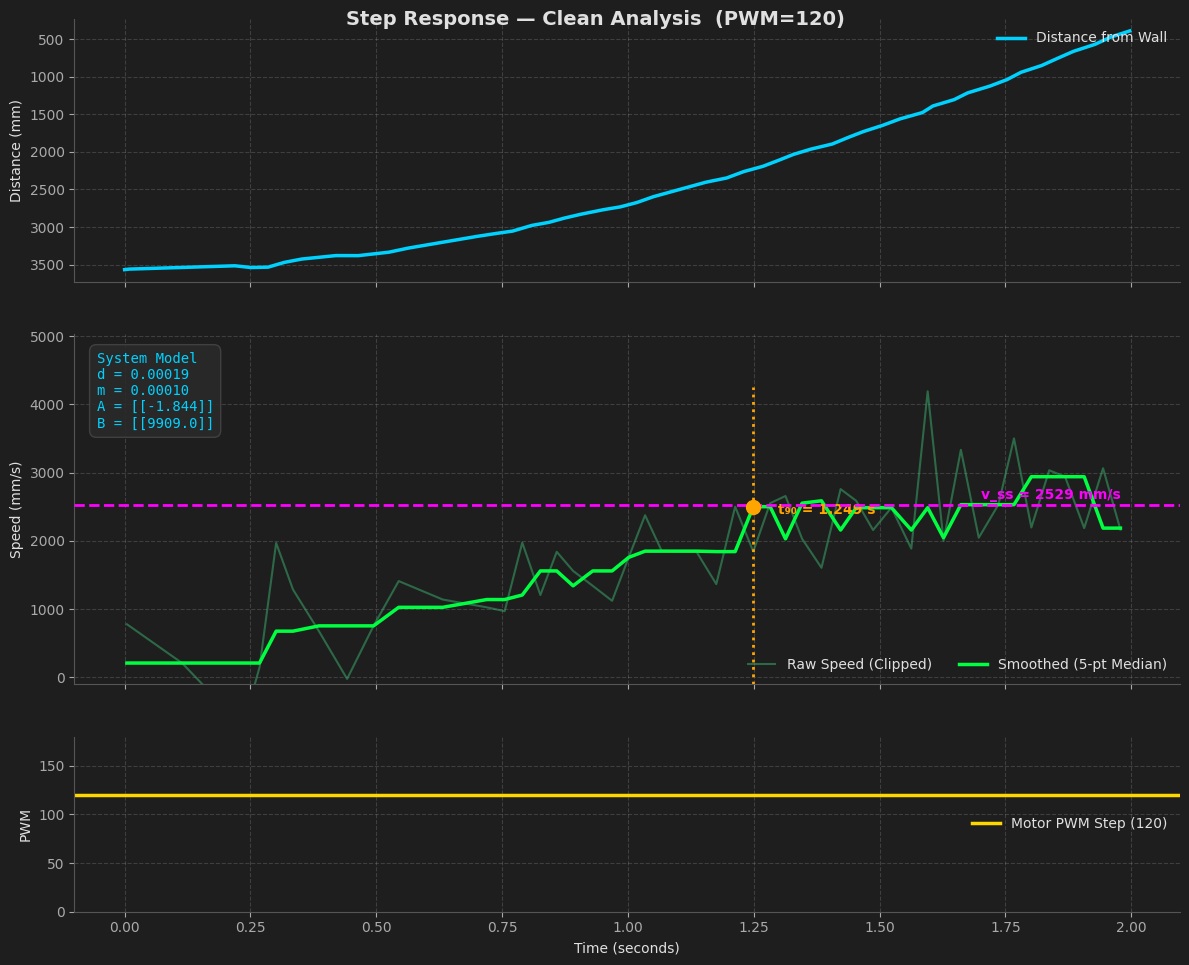

Saved → step_response_dark.png


In [56]:
# ── CELL: Clean Step Response Plot + KF Parameter Estimation ─────────────────
# Drop this after your existing parse cell (Cell 4).
# Requires: t, d1 arrays already loaded (same as your existing plot cell).
# Extra dependency: scipy  →  pip install scipy
from scipy.ndimage import median_filter
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Drop initial stuck phase ───────────────────────────────────────────────
diffs_raw  = np.abs(np.diff(d1))
first_real = np.argmax(diffs_raw > 5)

t_raw = t[first_real:].copy()
d_raw = d1[first_real:].copy()
t_raw = t_raw - t_raw[0]   # re-zero time to moment of first real movement

# ── 2. Deduplicate ────────────────────────────────────────────────────────────
mask = np.concatenate(([True], np.diff(d_raw) != 0))
t_u  = t_raw[mask]
d_u  = d_raw[mask]

# ── 3. Speed between consecutive unique readings ──────────────────────────────
dt_u    = np.diff(t_u)
speed_u = -np.diff(d_u) / dt_u      # mm/s
t_s     = (t_u[:-1] + t_u[1:]) / 2  # midpoint timestamps for each interval

# ── 4. Clip outliers before smoothing ────────────────────────────────────────
med        = np.median(speed_u)
iqr        = np.percentile(speed_u, 75) - np.percentile(speed_u, 25)
speed_clip = np.clip(speed_u, med - 3*iqr, med + 3*iqr)

# ── 5. Median filter smooth ───────────────────────────────────────────────────
speed_sm = median_filter(speed_clip, size=5)

# ── 6. Steady-state speed ─────────────────────────────────────────────────────
ss_idx = int(0.75 * len(speed_sm))
v_ss   = np.median(speed_sm[ss_idx:])

# ── 7. 90% rise time ─────────────────────────────────────────────────────────
v_90   = 0.90 * v_ss
idx_90 = np.argmax(speed_sm >= v_90)
t_90   = t_s[idx_90] if idx_90 > 0 else float('nan')

# ── 8. KF parameter estimation ────────────────────────────────────────────────
STEP_PWM_VALUE = int(mot[mot != 0][0]) if any(mot != 0) else 150
u_norm = STEP_PWM_VALUE / 255.0   # normalised input [0,1]
d_est  = u_norm / v_ss
m_est  = d_est * t_90 / np.log(10)

print("─" * 50)
print(f"  Unique ToF readings : {len(t_u)}")
print(f"  Duration            : {t_u[-1]:.3f} s")
print(f"  Travel              : {d_u[0]:.0f} → {d_u[-1]:.0f} mm")
print(f"  v_ss                : {v_ss:.1f} mm/s")
print(f"  t_90                : {t_90:.3f} s")
print(f"  d  (drag)           : {d_est:.6f}")
print(f"  m  (momentum)       : {m_est:.6f}")
print(f"  A  = [[-d/m]]       : [[{-d_est/m_est:.4f}]]")
print(f"  B  = [[1/m]]        : [[{1/m_est:.2f}]]")
print("─" * 50)
# ── 9. Plot (Dark Theme Styling) ──────────────────────────────────────────────
# Apply matplotlib's built-in dark theme as a base, then customize
plt.style.use('dark_background')

# Custom dark grey background (matches typical notebook/IDE dark themes)
BG_COLOR = '#1e1e1e'
TEXT_COLOR = '#e0e0e0'
GRID_COLOR = '#ffffff'

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True, 
                                    gridspec_kw={'height_ratios': [1.5, 2, 1]})

fig.patch.set_facecolor(BG_COLOR)
fig.suptitle(f'Step Response — Clean Analysis  (PWM={STEP_PWM_VALUE})',
             fontsize=14, fontweight='bold', y=0.96, color=TEXT_COLOR)

# Helper function to style axes for dark mode
def style_dark_axes(ax):
    ax.set_facecolor(BG_COLOR)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555')
    ax.spines['bottom'].set_color('#555555')
    ax.tick_params(colors='#aaaaaa', which='both')
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.grid(True, linestyle='--', color=GRID_COLOR, alpha=0.15)

# — Plot 1: Distance ——————————————————————————————————————————————————————————
ax1.plot(t_u, d_u, color='#00d2ff', linewidth=2.5, label='Distance from Wall')
ax1.set_ylabel('Distance (mm)')
ax1.invert_yaxis()
ax1.legend(loc='upper right', frameon=False, fontsize=10, labelcolor=TEXT_COLOR)
style_dark_axes(ax1)

# — Plot 2: Speed —————————————————————————————————————————————————————————————
ax2.plot(t_s, speed_clip, color='#3cb371', linewidth=1.5, alpha=0.5,
         label='Raw Speed (Clipped)')
ax2.plot(t_s, speed_sm, color='#00ff41', linewidth=2.5,
         label='Smoothed (5-pt Median)')

# Annotations (v_ss and t_90)
ax2.axhline(v_ss, color='#ff00ff', linestyle='--', linewidth=2, zorder=4)
ax2.text(t_s[-1], v_ss + 40, f'v_ss = {v_ss:.0f} mm/s', color='#ff00ff', 
         fontweight='bold', ha='right', va='bottom')

ax2.axvline(t_90, color='#ffa500', linestyle=':', linewidth=2, ymax=0.85)
ax2.scatter([t_90], [speed_sm[idx_90]], color='#ffa500', zorder=6, s=100)
ax2.text(t_90 + 0.05, speed_sm[idx_90] - 100, f't₉₀ = {t_90:.3f} s', color='#ffa500', 
         fontweight='bold', ha='left')

ax2.set_ylabel('Speed (mm/s)')
ax2.set_ylim([-100, max(speed_clip) * 1.2])
ax2.legend(loc='lower right', frameon=False, fontsize=10, ncol=2, labelcolor=TEXT_COLOR)
style_dark_axes(ax2)

# KF Params Box
kf_text = (f"System Model\n"
           f"d = {d_est:.5f}\n"
           f"m = {m_est:.5f}\n"
           f"A = [[{-d_est/m_est:.3f}]]\n"
           f"B = [[{1/m_est:.1f}]]")
ax2.text(0.02, 0.95, kf_text, transform=ax2.transAxes, fontsize=10,
         va='top', ha='left', family='monospace', color='#00d2ff',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#2a2a2a', edgecolor='#444444', alpha=0.9))

# — Plot 3: Motor input ————————————————————————————————————————————————————————
ax3.axhline(STEP_PWM_VALUE, color='#ffd700', linewidth=2.5,
            label=f'Motor PWM Step ({STEP_PWM_VALUE})')
ax3.set_ylim([0, STEP_PWM_VALUE * 1.5])
ax3.set_xlabel('Time (seconds)')
ax3.set_ylabel('PWM')
ax3.legend(loc='center right', frameon=False, fontsize=10, labelcolor=TEXT_COLOR)
style_dark_axes(ax3)

plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.savefig('step_response_dark.png', dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → step_response_dark.png")

──────────────────────────────────────────────────
  Unique ToF readings : 49
  Duration            : 1.997 s
  Travel              : 3566 → 391 mm
  v_ss                : 2529.4 mm/s
  t_90                : 1.249 s
  d  (drag)           : 0.000186
  m  (momentum)       : 0.000101
  A  = [[-d/m]]       : [[-1.8435]]
  B  = [[1/m]]        : [[9909.04]]
──────────────────────────────────────────────────


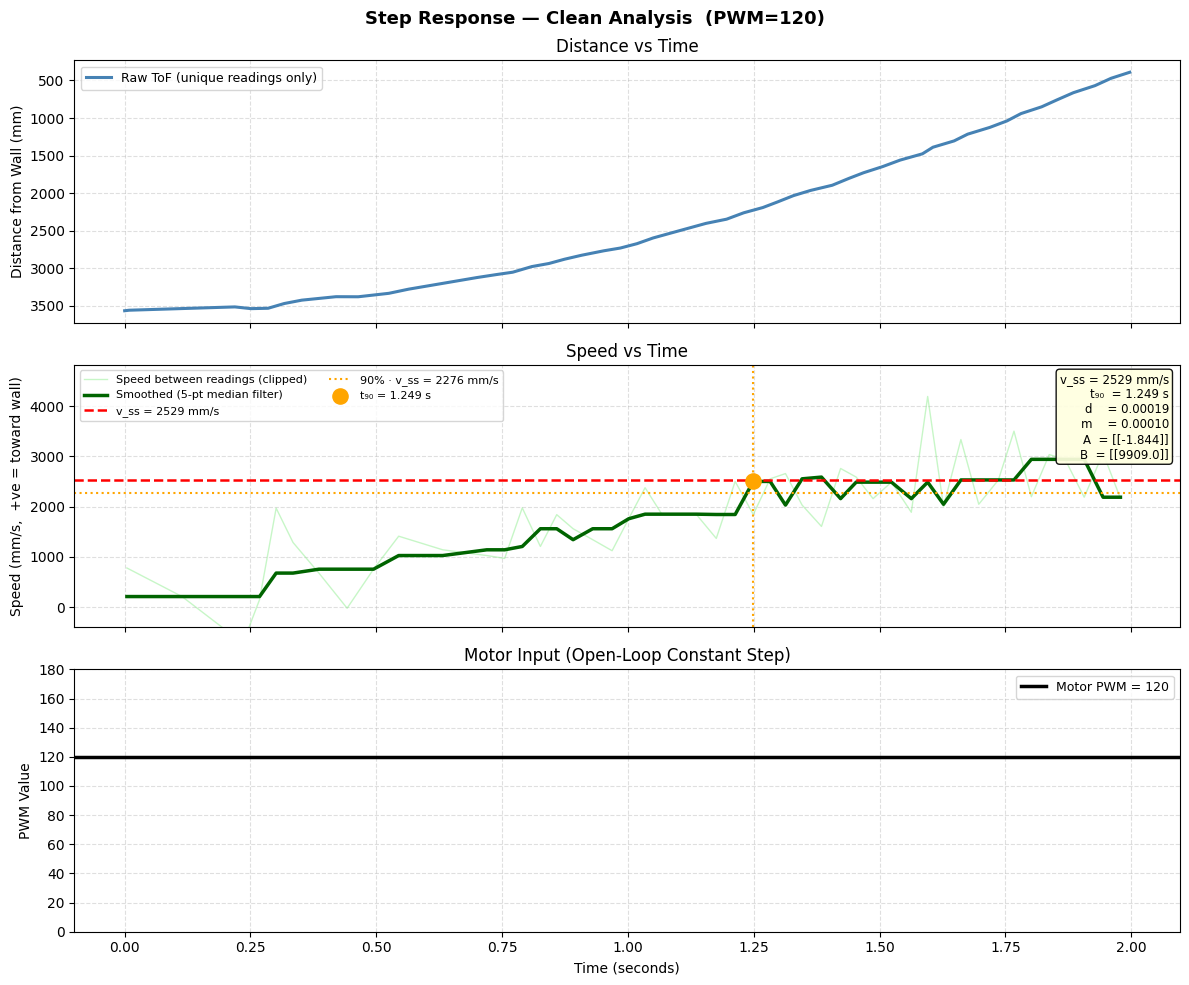

Saved → step_response_clean.png


In [54]:
# ── CELL: Clean Step Response Plot + KF Parameter Estimation ─────────────────
# Drop this after your existing parse cell (Cell 4).
# Requires: t, d1 arrays already loaded (same as your existing plot cell).
# Extra dependency: scipy  →  pip install scipy
from scipy.ndimage import median_filter
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Drop initial stuck phase ───────────────────────────────────────────────
# Sensor returns a fixed value before the robot moves enough to register.
# Find first index where distance actually changes by >5mm.
diffs_raw  = np.abs(np.diff(d1))
first_real = np.argmax(diffs_raw > 5)

t_raw = t[first_real:].copy()
d_raw = d1[first_real:].copy()
t_raw = t_raw - t_raw[0]   # re-zero time to moment of first real movement

# ── 2. Deduplicate ────────────────────────────────────────────────────────────
# ToF updates at ~27Hz but the loop logs at ~100Hz, so most rows are duplicates.
# np.gradient on duplicates creates divide-by-near-zero speed spikes.
# Only keep rows where the distance actually changed.
mask = np.concatenate(([True], np.diff(d_raw) != 0))
t_u  = t_raw[mask]
d_u  = d_raw[mask]

# ── 3. Speed between consecutive unique readings ──────────────────────────────
# Positive = toward wall (distance decreasing = robot approaching)
dt_u    = np.diff(t_u)
speed_u = -np.diff(d_u) / dt_u      # mm/s
t_s     = (t_u[:-1] + t_u[1:]) / 2  # midpoint timestamps for each interval

# ── 4. Clip outliers before smoothing ────────────────────────────────────────
# Spikes from occasional large ToF jumps (sensor noise, surface reflections).
# Clip anything beyond 3 IQR from the median — preserves the real signal shape.
med        = np.median(speed_u)
iqr        = np.percentile(speed_u, 75) - np.percentile(speed_u, 25)
speed_clip = np.clip(speed_u, med - 3*iqr, med + 3*iqr)

# ── 5. Median filter smooth ───────────────────────────────────────────────────
# 5-point median filter: removes remaining impulse noise without smearing edges.
# Increase size to 7 if still noisy; decrease to 3 to preserve more dynamics.
speed_sm = median_filter(speed_clip, size=5)

# ── 6. Steady-state speed ─────────────────────────────────────────────────────
# Use the last 25% of the run where speed should be flat (fully accelerated).
# Median is more robust than mean when there are still occasional spikes.
ss_idx = int(0.75 * len(speed_sm))
v_ss   = np.median(speed_sm[ss_idx:])

# ── 7. 90% rise time ─────────────────────────────────────────────────────────
v_90   = 0.90 * v_ss
idx_90 = np.argmax(speed_sm >= v_90)
t_90   = t_s[idx_90] if idx_90 > 0 else float('nan')

# ── 8. KF parameter estimation ────────────────────────────────────────────────
# 1D model:  ẋ = -(d/m)·x + (1/m)·u
# Steady state (ẋ=0): u = d·v_ss  →  d = u/v_ss
# First-order rise:   t_90 = (m/d)·ln(10)  →  m = d·t_90/ln(10)
u_norm = STEP_PWM_VALUE / 255.0   # normalised input [0,1]
d_est  = u_norm / v_ss
m_est  = d_est * t_90 / np.log(10)

print("─" * 50)
print(f"  Unique ToF readings : {len(t_u)}")
print(f"  Duration            : {t_u[-1]:.3f} s")
print(f"  Travel              : {d_u[0]:.0f} → {d_u[-1]:.0f} mm")
print(f"  v_ss                : {v_ss:.1f} mm/s")
print(f"  t_90                : {t_90:.3f} s")
print(f"  d  (drag)           : {d_est:.6f}")
print(f"  m  (momentum)       : {m_est:.6f}")
print(f"  A  = [[-d/m]]       : [[{-d_est/m_est:.4f}]]")
print(f"  B  = [[1/m]]        : [[{1/m_est:.2f}]]")
print("─" * 50)

# ── 9. Plot ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle(f'Step Response — Clean Analysis  (PWM={STEP_PWM_VALUE})',
             fontsize=13, fontweight='bold')

# — Distance ——————————————————————————————————————————————————————————————————
ax1.plot(t_u, d_u, color='steelblue', linewidth=2.2,
         label='Raw ToF (unique readings only)')
ax1.set_ylabel('Distance from Wall (mm)')
ax1.set_title('Distance vs Time')
ax1.invert_yaxis()   # moving toward wall = upward
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

# — Speed ———————————————————————————————————————————————————————————————————
ax2.plot(t_s, speed_clip, color='lightgreen', linewidth=1,   alpha=0.5,
         label='Speed between readings (clipped)')
ax2.plot(t_s, speed_sm,   color='darkgreen',  linewidth=2.5,
         label='Smoothed (5-pt median filter)')
ax2.axhline(v_ss, color='red',    linestyle='--', linewidth=1.8,
            label=f'v_ss = {v_ss:.0f} mm/s')
ax2.axhline(v_90, color='orange', linestyle=':',  linewidth=1.5,
            label=f'90% · v_ss = {v_90:.0f} mm/s')
ax2.axvline(t_90, color='orange', linestyle=':',  linewidth=1.5)
ax2.scatter([t_90], [speed_sm[idx_90]], color='orange', zorder=6, s=120,
            label=f't₉₀ = {t_90:.3f} s')
ax2.set_ylabel('Speed (mm/s,  +ve = toward wall)')
ax2.set_title('Speed vs Time')
ax2.set_ylim([-400, max(speed_clip) * 1.15])
ax2.legend(fontsize=8, loc='upper left', ncol=2)
ax2.grid(True, linestyle='--', alpha=0.4)

# KF params annotation box
kf_text = (f"v_ss = {v_ss:.0f} mm/s\n"
           f"t₉₀  = {t_90:.3f} s\n"
           f"d    = {d_est:.5f}\n"
           f"m    = {m_est:.5f}\n"
           f"A  = [[{-d_est/m_est:.3f}]]\n"
           f"B  = [[{1/m_est:.1f}]]")
ax2.text(0.99, 0.97, kf_text, transform=ax2.transAxes, fontsize=8.5,
         va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.92))

# — Motor input ————————————————————————————————————————————————————————————————
ax3.axhline(STEP_PWM_VALUE, color='black', linewidth=2.5,
            label=f'Motor PWM = {STEP_PWM_VALUE}')
ax3.set_ylim([0, STEP_PWM_VALUE * 1.5])
ax3.set_xlabel('Time (seconds)')
ax3.set_ylabel('PWM Value')
ax3.set_title('Motor Input (Open-Loop Constant Step)')
ax3.legend(fontsize=9)
ax3.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('step_response_clean.png', dpi=150)
plt.show()
print("Saved → step_response_clean.png")